# 1. Objective

This stage evaluates weakly supervised pneumonia localization with the **already-trained Stage 8 CNN**. Ground-truth boxes do not participate in CAM inference, thresholding, clustering, or prediction; they are joined from the original RSNA labels only after predictions are produced, for evaluation.

# 2. Why CAM?

The classifier uses global average pooling followed by one linear layer. For Pneumonia class *c*, Class Activation Mapping computes `M_c(x) = sum_k w_k^c f_k(x)`, where `f_k` is a final convolutional feature map and `w_k^c` is that class's classifier weight. High positive CAM values identify spatial regions that contribute to the Pneumonia score. The normalized heatmap is thresholded and its 8-connected active regions are converted to candidate boxes.

In [2]:
import csv
import json
import sys
from pathlib import Path
from IPython.display import Image as DisplayImage, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "metadata").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "metadata").is_dir():
    raise FileNotFoundError("Could not locate the project root")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

THRESHOLD = 0.5
APPLY_TWO_SIGMA_FILTER = True
print(f"Project root: {ROOT}")
print(f"Configured CAM threshold: {THRESHOLD}")
print(f"Two-standard-deviation area filter: {APPLY_TWO_SIGMA_FILTER}")

Project root: c:\Users\Shreelakshmi Bhat\OneDrive\Desktop\Projects\ML-mini--Pneumonia-Diagnosis-Detection-and-Localisation-
Configured CAM threshold: 0.5
Two-standard-deviation area filter: True


# 3. Load CNN

The checkpoint loader verifies that the saved architecture and fixed-split hash match the Stage 8 model before loading its weights. It performs an explicit compatibility check for the final convolution maps and Pneumonia-class fully connected weights. No optimizer or training loop is invoked.

In [3]:
from src.localization.pipeline import load_cnn_checkpoint

cnn, device, checkpoint_info = load_cnn_checkpoint(ROOT)
print(f"Device: {device}")
print(json.dumps(checkpoint_info, indent=2))
print("Pneumonia-class FC weights:", tuple(cnn.cam_weights()[1].shape))

Device: cpu
{
  "checkpoint_path": "models/cnn_best.pth",
  "checkpoint_sha256": "75ae304214bbea8d9d8ec3857904419c4215d564ab6e50fc84f5ccd2b4c8833f",
  "checkpoint_epoch": 9,
  "parameter_count": 757154,
  "architecture": {
    "input_channels": 1,
    "input_size": [
      128,
      128
    ],
    "channels": [
      32,
      32,
      64,
      64,
      96,
      96,
      128,
      128,
      128,
      128
    ],
    "num_classes": 2,
    "kernel_size": 3,
    "padding": 1,
    "activation": "ReLU",
    "pooling": "2x2 max pooling after convolutional layers 2, 4, 6, and 8",
    "global_pooling": "Adaptive Average Pooling to 1x1",
    "classifier": "one linear layer"
  },
  "cam_compatibility": {
    "convolution_count": 10,
    "final_feature_map_shape": [
      128,
      8,
      8
    ],
    "classifier_weight_shape": [
      2,
      128
    ],
    "fully_connected_layer_count": 1,
    "cam_compatible": true
  },
  "split_metadata_sha256": "87e9ffeb7718ada206f75b00e773c915f0

# 4. CAM Generation

CAMs use class index 1 (Pneumonia) and the model's final post-ReLU convolutional feature maps. The existing 128 × 128 preprocessing and train-fitted normalization are reused. The inference helper accepts image IDs and paths only; box coordinates are not passed into CAM generation.

In [4]:
import numpy as np
import torch
from src.data.preprocessing import DEFAULT_STATS_PATH, load_normalization_stats, preprocess_image, read_dicom_pixels
from src.localization.cam import compute_cam
from src.localization.heatmap import colorize_heatmap, overlay_heatmap
from src.localization.pipeline import _read_test_positive_images, _safe_image_path
from src.models.cnn import INPUT_SIZE

stats = load_normalization_stats(ROOT / DEFAULT_STATS_PATH)
example_input = _read_test_positive_images(ROOT)[0]
example_path = _safe_image_path(ROOT, example_input["image_path"])
example_tensor = torch.from_numpy(preprocess_image(example_path, stats)).unsqueeze(0).unsqueeze(0).to(device)
with torch.inference_mode():
    example_logits, example_features = cnn.forward_with_features(example_tensor)
    example_prediction = int(example_logits.argmax(dim=1).item())
    example_probability = float(torch.softmax(example_logits, dim=1)[0, 1].item())
example_cam = compute_cam(
    cnn, example_tensor, class_index=1, output_size=INPUT_SIZE, feature_maps=example_features
)[0].cpu().numpy()
raw_pixels, pixel_scale = read_dicom_pixels(example_path)
source_display = np.clip(raw_pixels / pixel_scale, 0.0, 1.0)
example_heatmap = colorize_heatmap(example_cam)
example_overlay = overlay_heatmap(source_display, example_cam, alpha=0.4)
print("Image ID:", example_input["image_id"])
print("Prediction:", "Pneumonia" if example_prediction == 1 else "Healthy")
print(f"Pneumonia probability: {example_probability:.4f}")
print("Final feature maps:", tuple(example_features.shape))
print("CAM shape/range:", example_cam.shape, float(example_cam.min()), float(example_cam.max()))
print("Color heatmap:", example_heatmap.shape, "overlay:", example_overlay.shape)

Image ID: 0087bd3a-55a7-4045-b111-b018fa52d361
Prediction: Pneumonia
Pneumonia probability: 0.9682
Final feature maps: (1, 128, 8, 8)
CAM shape/range: (128, 128) 0.0 0.9865866899490356
Color heatmap: (128, 128, 3) overlay: (1024, 1024, 3)


# 5. Heatmap

The CAM is ReLU-clipped and min-max normalized per image, then bilinearly resized to 128 × 128 for thresholding and to the DICOM dimensions for visualization. **Threshold 0.5** is the configurable experiment setting used here; it is not claimed to be a universal threshold specified by the paper. The script accepts another threshold with `--threshold`.

In [5]:
print("Smoke-test mode: only one test image is processed; full-set localization is not run.")
print(r'Later full evaluation: .venv-1\Scripts\python.exe scripts\run_cam_localization.py')

Smoke-test mode: only one test image is processed; full-set localization is not run.
Later full evaluation: .venv-1\Scripts\python.exe scripts\run_cam_localization.py


# 6. Clustering

Activated pixels satisfy `CAM >= threshold`. An iterative 8-neighbor depth-first search visits each active pixel once and returns one cluster per connected region. Clustering is performed at the 128 × 128 CAM resolution to preserve useful spatial detail without traversing a million-pixel 1024 × 1024 mask per image.

Activated pixels: 1,516
DFS clusters: 1
Predicted boxes after optional area filtering: 1
First boxes (x, y, width, height): [(344.0, 600.0, 304.0, 424.0)]


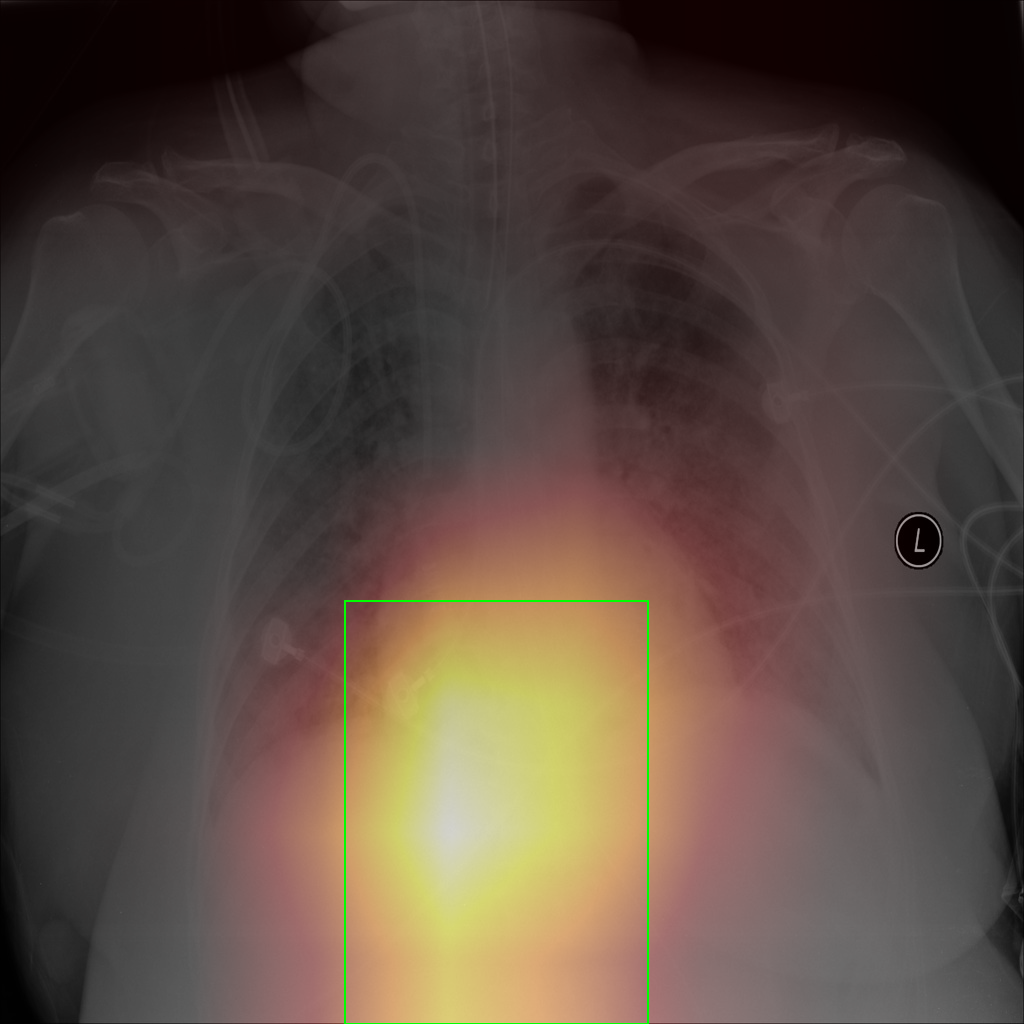

In [6]:
from PIL import Image as PILImage, ImageDraw
from src.localization.bounding_box import activated_mask, clusters_to_boxes
from src.localization.clustering import find_clusters
from src.localization.pipeline import _dicom_dimensions

active = activated_mask(example_cam, THRESHOLD)
example_clusters = find_clusters(active)
original_height, original_width = _dicom_dimensions(example_path)
example_boxes = clusters_to_boxes(
    example_clusters,
    map_size=example_cam.shape,
    image_size=(original_height, original_width),
    apply_two_sigma=APPLY_TWO_SIGMA_FILTER,
)
print(f"Activated pixels: {int(active.sum()):,}")
print(f"DFS clusters: {len(example_clusters)}")
print(f"Predicted boxes after optional area filtering: {len(example_boxes)}")
print("First boxes (x, y, width, height):", example_boxes[:5])
if example_boxes:
    rendered = PILImage.fromarray(example_overlay.copy())
    drawer = ImageDraw.Draw(rendered)
    scale_x = rendered.width / original_width
    scale_y = rendered.height / original_height
    for x, y, width, height in example_boxes:
        drawer.rectangle((x * scale_x, y * scale_y, (x + width) * scale_x, (y + height) * scale_y), outline=(0, 255, 0), width=2)
    display(rendered)
else:
    print("No candidate box survived thresholding and the configured cluster filter.")

# 7. Bounding Box Prediction

Each cluster is bounded by its minimum/maximum x and y pixel coordinates. The inclusive pixel extent is scaled from 128 × 128 CAM coordinates to the original DICOM width and height. The optional paper-inspired 2-SD filter is made explicit: per image, retain clusters whose activated-pixel counts lie within the mean ± 2 population standard deviations. This is a documented implementation choice because the supplied paper description does not specify the precise statistic or filtering direction.

# 8. Ground Truth

For evaluation, positive (`Target=1`) boxes are read from `Data/stage_2_train_labels.csv` after prediction and restricted to Pneumonia-positive IDs in the fixed test split. Multiple boxes for one image are retained separately. The saved full-set evaluation covers the 601 Pneumonia-positive test images; ground-truth boxes are not passed into CAM generation.

# 9. IoU

For multiple predicted and ground-truth boxes, all pairwise IoUs are sorted descending and matched greedily one-to-one. Per-image IoU is the matched IoU sum divided by the larger of the predicted/ground-truth box counts; unmatched boxes contribute zero. These are the documented local evaluation rules used by the saved Stage 9 result.

In [7]:
from src.localization.iou import box_iou, image_iou

smoke_box = (10.0, 20.0, 30.0, 40.0)
assert box_iou(smoke_box, smoke_box) == 1.0
assert image_iou([smoke_box], [smoke_box]) == 1.0
print("IoU helper smoke checks passed; no dataset-level metrics were calculated.")

IoU helper smoke checks passed; no dataset-level metrics were calculated.


# 10. Results

The table below reports the existing Stage 9 result from `results/cam_results.json`; CAM was not rerun during finalization. It is evaluated on the 601 Pneumonia-positive examples in the fixed test split.

In [ ]:
display(Markdown(
    "| Model | Reference Test IoU | Our Test IoU | Difference |\n|---|---:|---:|---:|\n"
    "| CNN + CAM | 0.1508 | 0.080087 | -0.070713 |"
))

# 11. Visual Results

The single-image example cell displays one in-memory CAM overlay. The completed Stage 9 pipeline also saved its small set of selected visual examples under `results/cam_examples/`; the localization summary is in `results/cam_results.json`.

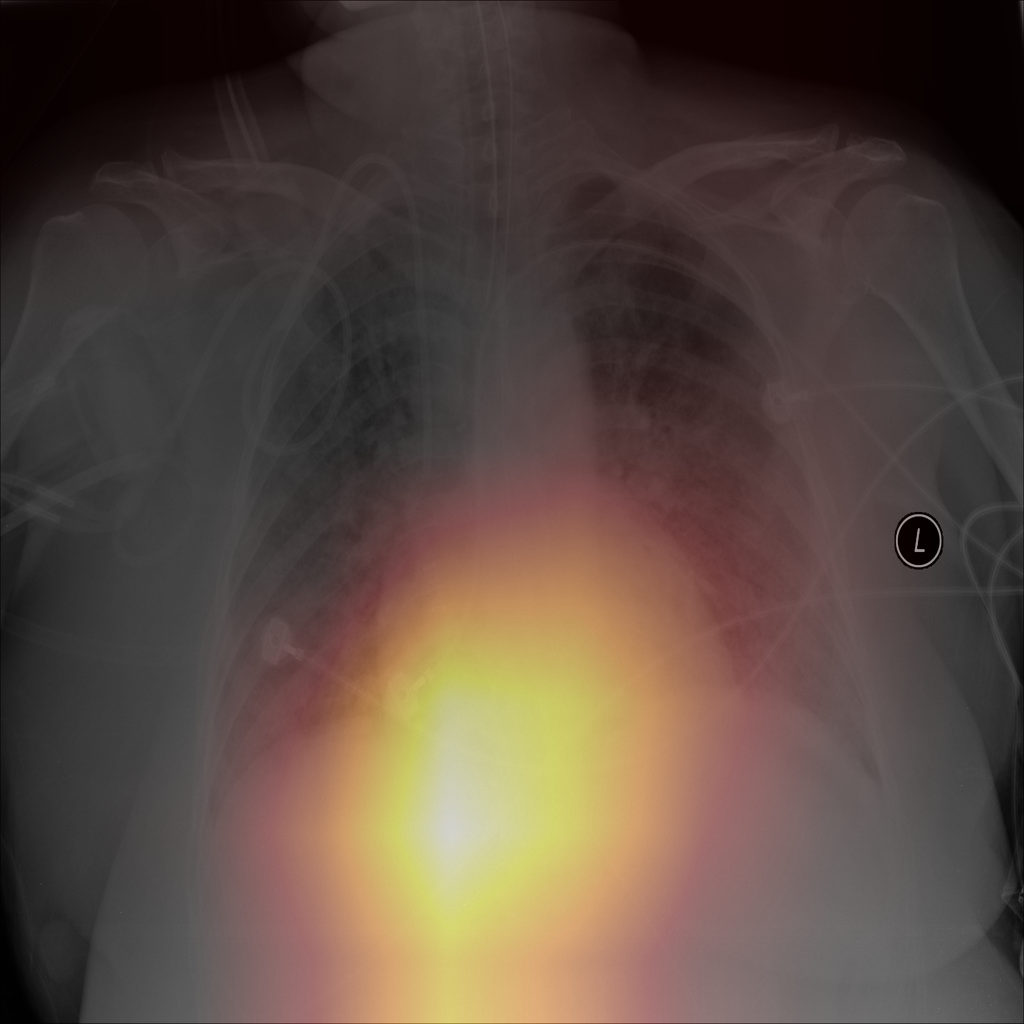

In [9]:
display(PILImage.fromarray(example_overlay))

# 12. Discussion

The single-image notebook example illustrates the inference-to-box code path; the saved dataset-level result evaluates all 601 Pneumonia-positive images in the fixed test split. The configurable threshold and optional area filter are explicit operational choices because the supplied paper description does not specify their exact implementation. Mean IoU is 0.080087 versus the paper-reported 0.1508. The local usable cohort (14,863 labeled images) differs from the paper's reported 17,489-image cohort, so this is a documented reproduction attempt rather than an exact replication claim.